In [34]:
import os
import random
from PIL import Image
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses, callbacks, regularizers
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

seed = 42
os.environ['PYTHONHASHSEED'] = str(seed)
os.environ["TF_DETERMINISTIC_OPS"] = "-1"
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
tf.config.experimental.enable_op_determinism()

IMG_HEIGHT = 64
IMG_WIDTH = 64
BATCH_SIZE = 128
num_classes = 3
learning_rate = 1e-4
epoch = 20


In [35]:
#pgmを使うならこっち
data_dir = "C:/Users/torat/Desktop/sotsuken/sotsuken/images_350_weight_pgm"
unlabeled_dir = "C:/Users/torat/Desktop/sotsuken/sotsuken/unlabeled_dir_weight_pgm"
label_dict = {
    # Mild (0)
    'AF483470.1': 0, 'EF192393.1': 0, 'EF192394.1': 0,
    'EF580923.1': 0, 'EU879915.1': 0, 'EU879916.1': 0,
    'JQ806338.1': 0, 'KF418767.1': 0, 'KR611355.1': 0,
    'KT987925.1': 0, 'LC388852.1': 0, 'LC388854.1': 0,
    'M25199.1': 0, 'MG450357.1': 0, 'Y09575.1': 0,

    # Moderate (1)
    'AF454395.1': 1, 'KF683200.1': 1, 'KJ857496.1': 1,
    'KR611360.1': 1, 'M88678.1': 1, 'X17268.1': 1,
    'GQ853461.1': 1, 'EU879913.1': 1,

    # Severe (2)
    'AJ634596.1': 2, 'AY518939.1': 2, 'AY532801.1': 2,
    'DD220185.1': 2, 'FR851463.1': 2, 'JX280944.1': 2,
    'U23060.1': 2, 'X58388.1': 2, 'X76846.1': 2,
    'X97387.1': 2, 'Y09383.1': 2, 'LC523672.1': 2,
    'LC523675.1': 2, 'LC523676.1': 2
}

# 元のファイル名（拡張子なし）
labeled_bases = list(label_dict.keys())
labels = list(label_dict.values())


filepaths = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith(".pgm")]

# 水増しファイルをオリジナルごとにマッピング
original_to_aug = {}
for orig_base in labeled_bases:
    aug_files = [f for f in os.listdir(data_dir) if f.startswith(orig_base + '_shift') and f.endswith('.pgm')]
    aug_files_sorted = sorted(aug_files, key=lambda x: int(x.split('_shift')[1].split('.')[0]))  # start000からソート
    original_to_aug[orig_base] = [os.path.join(data_dir, f) for f in aug_files_sorted]

# 未ラベルファイル: unlabeled_dirの全ファイル
unlabeled_fullpaths = [os.path.join(unlabeled_dir, f) for f in os.listdir(unlabeled_dir) if f.endswith(".pgm")]

# 水増し数確認（仮定: 各オリジナルあたり350）
aug_count = 350  # 各オリジナルあたりの水増し数（実際の数に合わせて調整）

label_map = {0: "mild", 1: "moderate", 2: "severe"}

print(f"ラベル付きオリジナルの数: {len(labeled_bases)}")
print(f"全ファイル数: {len(filepaths)}")
print(f"未ラベルファイルの数: {len(unlabeled_fullpaths)}")

ラベル付きオリジナルの数: 37
全ファイル数: 13276
未ラベルファイルの数: 270


In [36]:
def load_and_preprocess_list(fp_list):
    X = []
    for p in fp_list:
        img = np.array(Image.open(p))
        img = img.reshape(64, 64, 1)
        img = img.astype('float32')
        img /= 255
        X.append(img)
    return np.array(X)

In [37]:
def make_model():
    model = models.Sequential()
    model.add(layers.Conv2D(16, (3,3), activation='relu', input_shape=(64, 64, 1)))
    model.add(layers.MaxPool2D((2,2)))
    model.add(layers.Conv2D(32, (3,3), activation='relu'))
    model.add(layers.MaxPool2D((2,2)))
    model.add(layers.Conv2D(64, (3,3), activation='relu'))
    model.add(layers.MaxPool2D((2,2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

In [38]:
def jackknife_on_files(labeled_bases, labels, unlabeled_paths, epochs, verbose=1):
    n = len(labeled_bases)
    val_accs = []
    val_records = []

    # 元のファイル名（拡張子付き）で予測結果を記録するための辞書
    labeled_pbm = [base + '.pgm' for base in labeled_bases]  # 元の形式に戻す

    for i in range(n):
        print(f"\nFold {i+1}/{n} ")
        orig_base_i = labeled_bases[i]
        # test: start000.pgm
        test_path = original_to_aug[orig_base_i][0]  # ソート済みなので[0]がstart000
        x_test = load_and_preprocess_list([test_path])
        y_test = np.array([labels[i]], dtype=np.int32)

        val_name = orig_base_i + '.pgm'  # 元の形式
        val_true_label = label_map[int(y_test[0])]

        # train_paths: 他のオリジナルの全水増し
        train_paths = []
        train_labels = []
        for j in range(n):
            if j != i:
                train_paths.extend(original_to_aug[labeled_bases[j]])
                train_labels.extend([labels[j]] * len(original_to_aug[labeled_bases[j]]))

        x_train = load_and_preprocess_list(train_paths)
        y_train = np.array(train_labels, dtype=np.int32)

        early_stop = callbacks.EarlyStopping(
            monitor='loss',
            patience=5,
            restore_best_weights=True
        )

        model = make_model()
        model.compile(optimizer=optimizers.Adam(learning_rate),
                      loss=losses.SparseCategoricalCrossentropy(),
                      metrics=['sparse_categorical_accuracy'])

        history = model.fit(x_train, y_train, batch_size=BATCH_SIZE, epochs=epochs, verbose=verbose, callbacks=[early_stop])

        pred_history = model.predict(x_test)
        plt.figure(figsize=(10, 6))

        results.append(history.history)
        pred_results.append([val_name, pred_history])

In [39]:
results = []
pred_results = []
records = []
stopped_epochs = []

jackknife_on_files(labeled_bases, labels, unlabeled_fullpaths, epochs=epoch, verbose=1)

img_ext = os.listdir(data_dir)[0].split('.')[-1] if os.listdir(data_dir) else 'pgm'
lr_str = "{:.0e}".format(learning_rate)
output_dir = f"{num_classes}classes_weight_350_epoch{epoch}_{lr_str}_{img_ext}"
os.makedirs(output_dir, exist_ok=True)

mat_dir = os.path.join(output_dir, "mat")
acc_dir = os.path.join(output_dir, "acc")
fold_loss_dir = os.path.join(output_dir, "fold_loss")

for d in [mat_dir, acc_dir, fold_loss_dir]:
    os.makedirs(d, exist_ok=True)


Fold 1/37 
Epoch 1/20


C:\Users\torat\Desktop\sotsuken\sotsuken\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1.1510 - sparse_categorical_accuracy: 0.5465
Epoch 2/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.8374 - sparse_categorical_accuracy: 0.7123
Epoch 3/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.6038 - sparse_categorical_accuracy: 0.8194
Epoch 4/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.4662 - sparse_categorical_accuracy: 0.8783
Epoch 5/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.3759 - sparse_categorical_accuracy: 0.9199
Epoch 6/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.3138 - sparse_categorical_accuracy: 0.9438
Epoch 7/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.2685 - sparse_categorical_accuracy: 0.9606
Epoch 8/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.2419 - sparse_categorical_accuracy: 0.9699
Epoch 9/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.2187 - sparse_categorical_accuracy: 0.9762
Epoch 10/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - l

C:\Users\torat\AppData\Local\Temp\ipykernel_43132\2579659373.py:45: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 6))


Epoch 1/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1.1586 - sparse_categorical_accuracy: 0.5398
Epoch 2/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.8872 - sparse_categorical_accuracy: 0.6996
Epoch 3/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.6462 - sparse_categorical_accuracy: 0.8062
Epoch 4/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.4949 - sparse_categorical_accuracy: 0.8701
Epoch 5/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.3905 - sparse_categorical_accuracy: 0.9155
Epoch 6/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.3200 - sparse_categorical_accuracy: 0.9397
Epoch 7/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.2685 - sparse_categorical_accuracy: 0.9587
Epoch 8/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.2361 - sparse_categorical_accuracy: 0.9679
Epoch 9/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.2106 - sparse_categorical_accuracy: 0.9769
Epoch 10/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 14

...

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

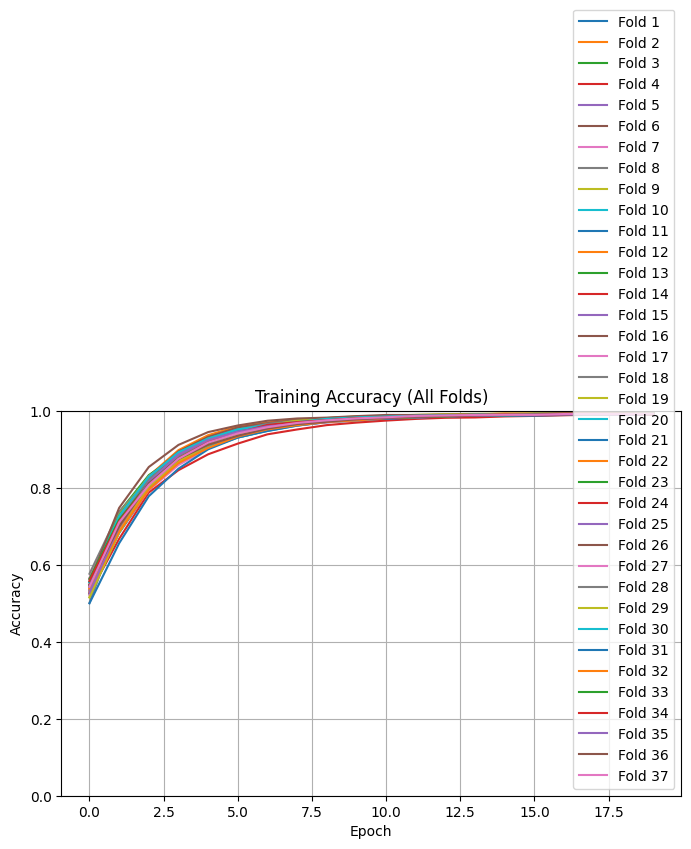

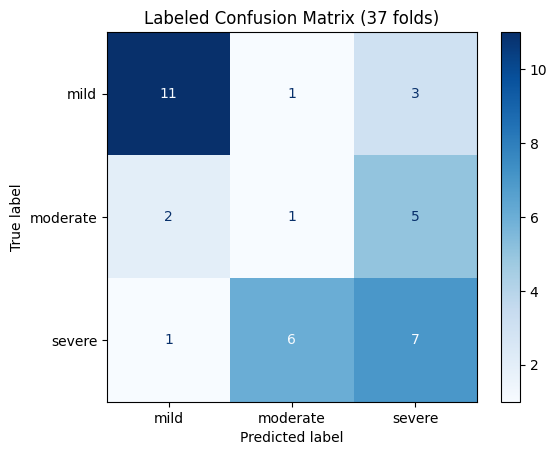

In [40]:
for i, r in enumerate(results):
    plt.figure(figsize=(8, 5))
    plt.plot(r["loss"], label="Train Loss", color="blue")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Fold {i + 1} - Train Loss")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(fold_loss_dir, f"fold_{i + 1}_loss.png"))
    plt.close()

for i, r in enumerate(results):
    plt.figure(figsize=(8, 5))
    plt.plot(r["sparse_categorical_accuracy"], label="Train Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.ylim([0, 1])
    plt.title(f"Fold {i + 1} - Train Accuracy")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(acc_dir, f"fold_{i + 1}_accuracy.png"))
    plt.close()

plt.figure(figsize=(8, 5))
for i in range(len(results)):
    plt.plot(results[i]['sparse_categorical_accuracy'], label=f'Fold {i + 1}')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.title("Training Accuracy (All Folds)")
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig(os.path.join(acc_dir, "all_folds_accuracy.png"))
plt.show()
plt.close()

pred_labels = []
true_labels = []
for i in range(len(pred_results)):
    pre = pred_results[i][1].tolist()
    pre = pre[0]
    pred_labels.append(pre.index(max(pre)))
    orig_base = '.'.join(pred_results[i][0].split('.')[:-1])
    true_labels.append(label_dict[orig_base])

fixed_labels = ["mild", "moderate", "severe"]
cm = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fixed_labels)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Labeled Confusion Matrix (37 folds)")
plt.savefig(os.path.join(mat_dir, "confusion_matrix.png"))
plt.show()
plt.close()

In [41]:
label_map = {0: "mild", 1: "moderate", 2: "severe"}

misclassified = []

for i in range(len(pred_results)):
    filename = pred_results[i][0]  # 'AF483470.1.pgm'
    probs = pred_results[i][1][0]
    pred_label = int(np.argmax(probs))
    orig_base = '.'.join(filename.split('.')[:-1])
    true_label = int(label_dict[orig_base])

    if pred_label != true_label:
        misclassified.append({
            "PBM_Name": filename,
            "True_Label": label_map[true_label],
            "Pred_Label": label_map[pred_label],
            "Prob_mild": probs[0],
            "Prob_moderate": probs[1],
            "Prob_severe": probs[2]
        })

df_mis = pd.DataFrame(misclassified)
print("=== 誤分類されたサンプル ===")
print(df_mis)
df_mis.to_csv(os.path.join(output_dir, "misclassified_samples.csv"), index=False)

=== 誤分類されたサンプル ===
          PBM_Name True_Label Pred_Label     Prob_mild  Prob_moderate  \
0   AF483470.1.pgm       mild     severe  1.942091e-01   1.252726e-01   
1   EF192394.1.pgm       mild     severe  3.697122e-02   3.847997e-03   
2   JQ806338.1.pgm       mild     severe  3.245690e-03   2.501344e-03   
3     Y09575.1.pgm       mild   moderate  6.238983e-03   9.738461e-01   
4   AF454395.1.pgm   moderate     severe  3.474103e-06   3.748538e-05   
5   KF683200.1.pgm   moderate       mild  9.677135e-01   2.045905e-03   
6   KJ857496.1.pgm   moderate     severe  1.914343e-07   7.907055e-04   
7   KR611360.1.pgm   moderate       mild  9.997744e-01   2.129752e-04   
8     X17268.1.pgm   moderate     severe  2.444536e-05   8.822123e-05   
9   GQ853461.1.pgm   moderate     severe  5.278029e-06   2.307663e-04   
10  EU879913.1.pgm   moderate     severe  4.212597e-04   2.405026e-03   
11  AY532801.1.pgm     severe   moderate  3.555199e-06   9.997430e-01   
12  FR851463.1.pgm     severe   

C:\Users\torat\Desktop\sotsuken\sotsuken\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1.1525 - sparse_categorical_accuracy: 0.5539
Epoch 2/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.8408 - sparse_categorical_accuracy: 0.7263
Epoch 3/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.5972 - sparse_categorical_accuracy: 0.8309
Epoch 4/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.4570 - sparse_categorical_accuracy: 0.8871
Epoch 5/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.3606 - sparse_categorical_accuracy: 0.9241
Epoch 6/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.2994 - sparse_categorical_accuracy: 0.9510
Epoch 7/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.2617 - sparse_categorical_accuracy: 0.9634
Epoch 8/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.2345 - sparse_categorical_accuracy: 0.9730
Epoch 9/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.2125 - sparse_categorical_accuracy: 0.9782
Epoch 10/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 14

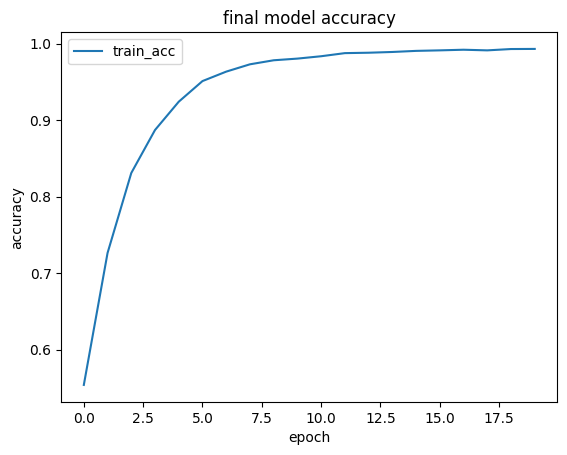

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Saved CSV: 3classes_epoch20_1e-04_pgm.csv
finish


In [42]:
final_early_stop = callbacks.EarlyStopping(
    monitor='loss',
    patience=5,
    restore_best_weights=True
)

final_model = make_model()
final_model.compile(optimizer=optimizers.Adam(learning_rate),
                    loss=losses.SparseCategoricalCrossentropy(),
                    metrics=['sparse_categorical_accuracy'])

# すべての水増しデータを訓練に使用
all_aug_paths = [path for paths in original_to_aug.values() for path in paths]
x_all = load_and_preprocess_list(all_aug_paths)
y_all = np.repeat(labels, [len(original_to_aug[base]) for base in labeled_bases], axis=0).astype(np.int32)

final_history = final_model.fit(x_all, y_all, batch_size=BATCH_SIZE, epochs=epoch, verbose=1, callbacks=[final_early_stop])

plt.plot(final_history.history["sparse_categorical_accuracy"], label="train_acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("final model accuracy")
plt.legend()
plt.savefig(os.path.join(acc_dir, "acc.png"))
plt.show()
plt.close()

final_model.save("jackknife_PSTVd_model.keras")

X_unlabeled = load_and_preprocess_list(unlabeled_fullpaths)

unlabeled_preds = final_model.predict(X_unlabeled)

pred_classes = np.argmax(unlabeled_preds, axis=1)
pred_labels = [label_map[c] for c in pred_classes]

df_pred = pd.DataFrame({
    "PBM_Name": [os.path.basename(fp) for fp in unlabeled_fullpaths],
    "Pred_Sym_Severity": pred_labels
})

csv_name = f"{num_classes}classes_epoch{epoch}_{lr_str}_{img_ext}.csv"
df_pred.to_csv(os.path.join(output_dir, csv_name), index=False)
print("Saved CSV:", csv_name)
print("finish")